In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import gc
from matplotlib import pyplot as plt
%run ../common.py
%run ../commonvis.py

In [44]:
def make_plot(df, methods):
    df_plot = df.copy()
    df_plot['neglog10p'] = -np.log10(df_plot['p'].clip(upper=0.9))

    datasets = df_plot['dataset'].unique()

    fig, axes = plt.subplots(1, len(datasets), figsize=(3 * len(datasets), 5), sharey=True)

    for i, dataset in enumerate(datasets):
        ax = axes[i] if len(datasets) > 1 else axes
        sub = df_plot[df_plot['dataset'] == dataset]
        
        x = np.arange(len(methods))
        bar_width = 0.8
        p_vals = []
        frac_neg = []
        frac_pos = []

        for j, method in enumerate(methods):
            row = sub[sub['method'] == method]
            if not row.empty:
                p_vals.append(row['neglog10p'].values[0])
                frac_neg.append(row['frac_neg'].values[0])
                frac_pos.append(row['frac_pos'].values[0])
            else:
                # Placeholder zeros for bars
                p_vals.append(0)
                frac_neg.append(0)
                frac_pos.append(0)

                # Determine label type
                if dataset in ['RA subtypes', 'UC vs healthy', 'Dementia vs control']:
                    label = 'NR'
                elif dataset == 'TNFi':
                    label = 'NA'
                else:
                    label = 'NA'  # fallback

                # Annotate with label
                ax.text(j, 0.1, label, ha='center', va='bottom', fontsize=9, color='black')

        # Plot upward P bars
        ax.bar(x, p_vals, color="#00d5ff", width=bar_width)

        # Plot downward stacked bars
        ax.bar(x, -4*np.array(frac_pos), color='red', width=bar_width, label='Positively associated')
        ax.bar(x, -4*np.array(frac_neg), bottom=-4*np.array(frac_pos),
            color='blue', width=bar_width, label='Negatively associated')
        ax.axhline(y=-np.log10(0.05), ls='--', color='gray')

        ax.set_xticks(x)
        ax.set_xticklabels([methodnames[m] for m in methods], rotation=45, ha='right')
        ax.set_yticks([-2,-1,0,1,2,3])
        ax.set_yticklabels(['50%', '25%', '0', '1', '2', '3'])
        ax.set_title(dataset)
        ax.axhline(0, color='black', lw=0.5)

    ### label y-axis
    # Get y-limits to position the text dynamically
    ymin, ymax = axes[0].get_ylim()

    # Label for the top (P-values)
    axes[0].text(
        -2.5,                     # x-position (adjust as needed)
        ymax * 0.5,               # y-position in upper half
        '$-\\log_{10}(P)$', 
        rotation=90,
        va='center',
        ha='center',
    )

    # Label for the bottom (Associations)
    axes[0].text(
        -2.5,
        ymin * 0.5,               # y-position in lower half
        '%Sig. spatial units', 
        rotation=90,
        va='center', 
        ha='center',
    )

    for ax in axes:
        ax.spines[['right', 'top']].set_visible(False)
    axes[-1].legend(loc='lower right')

    plt.tight_layout()

In [71]:
results = pd.read_csv('_results/allbenchmarking.csv')
omnibus = results[~(results.microniche == True)&~(results.harmonized == True)&~(results.bonferroni == True)].copy().reset_index(drop=True)
microniche = results[~(results.microniche == False)&~(results.harmonized == True)&~(results.bonferroni == True)].copy().reset_index(drop=True)
harmonized = results[~(results.microniche == True)&~(results.harmonized == False)&~(results.bonferroni == False)].copy().reset_index(drop=True)
bonferroni = results[~(results.microniche == True)&~(results.harmonized == True)&~(results.bonferroni == False)].copy().reset_index(drop=True)

harmonized_microniche = results[~(results.microniche == False)&~(results.harmonized == False)&~(results.bonferroni == True)].copy().reset_index(drop=True)

In [73]:
methodorder = bonferroni.sort_values(by='p').method.unique()

clusters, bonferroni


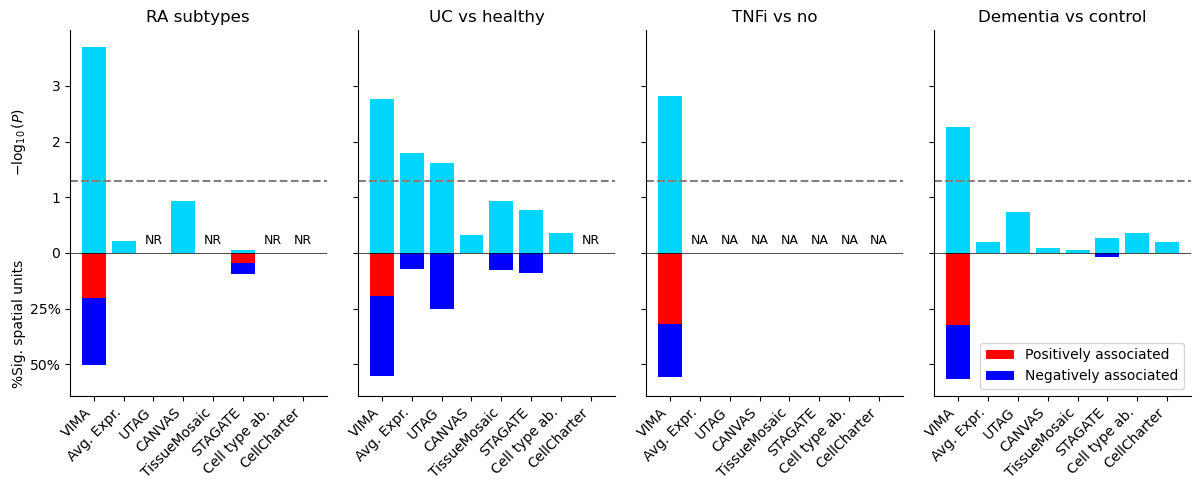

clusters, omnibus


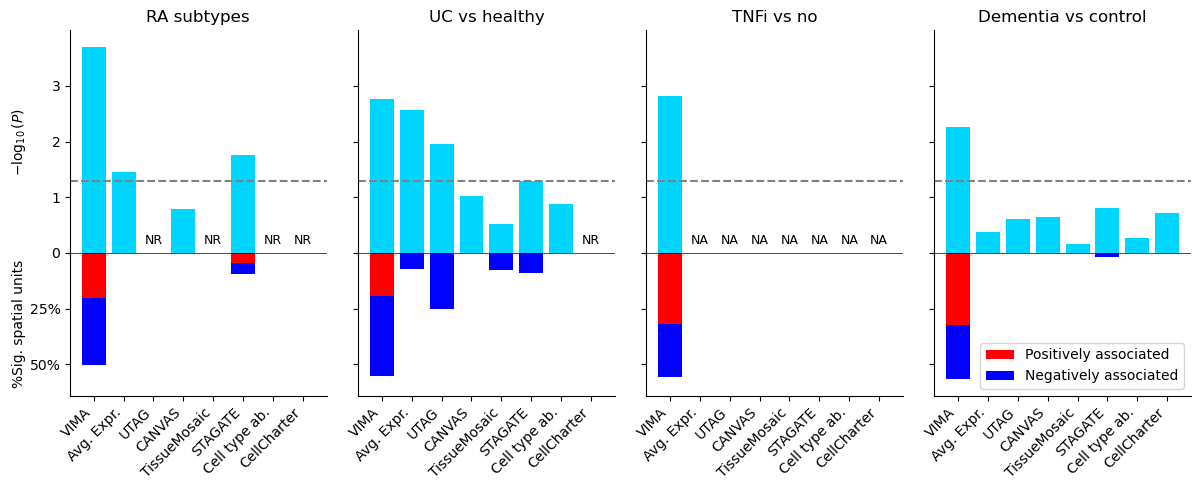

microniches


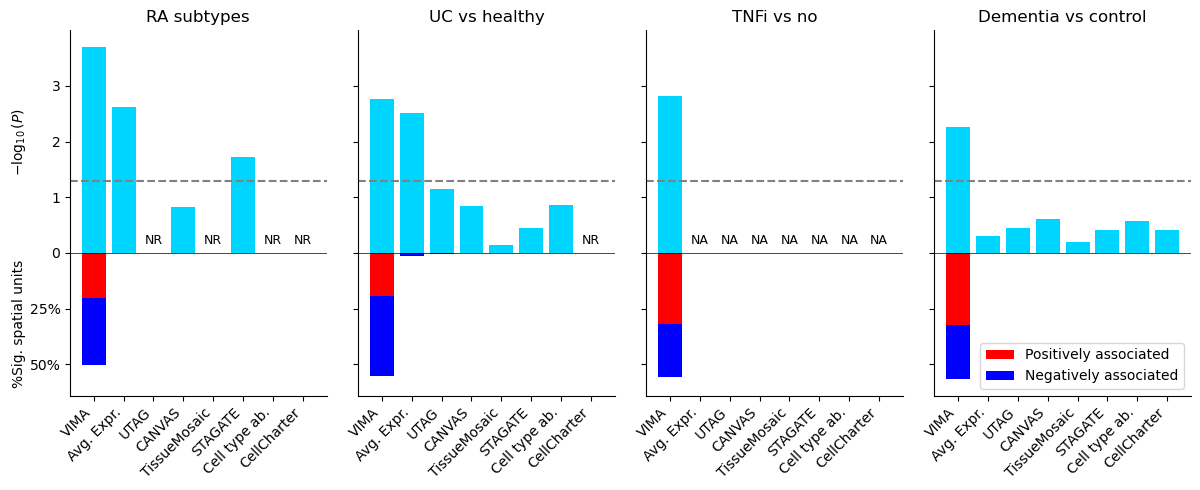

harmonized -> clusters, bonferroni


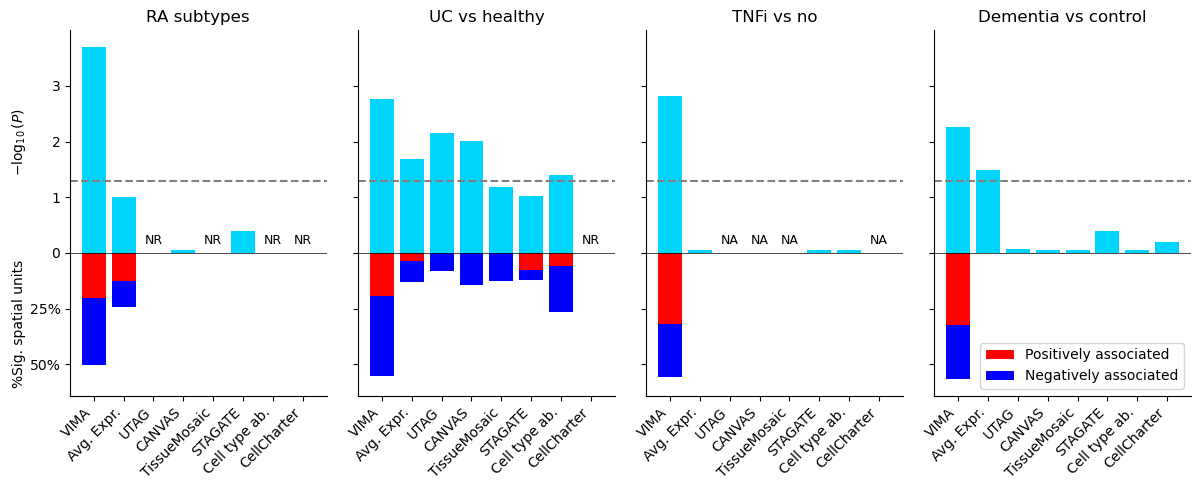

harmonized -> microniches


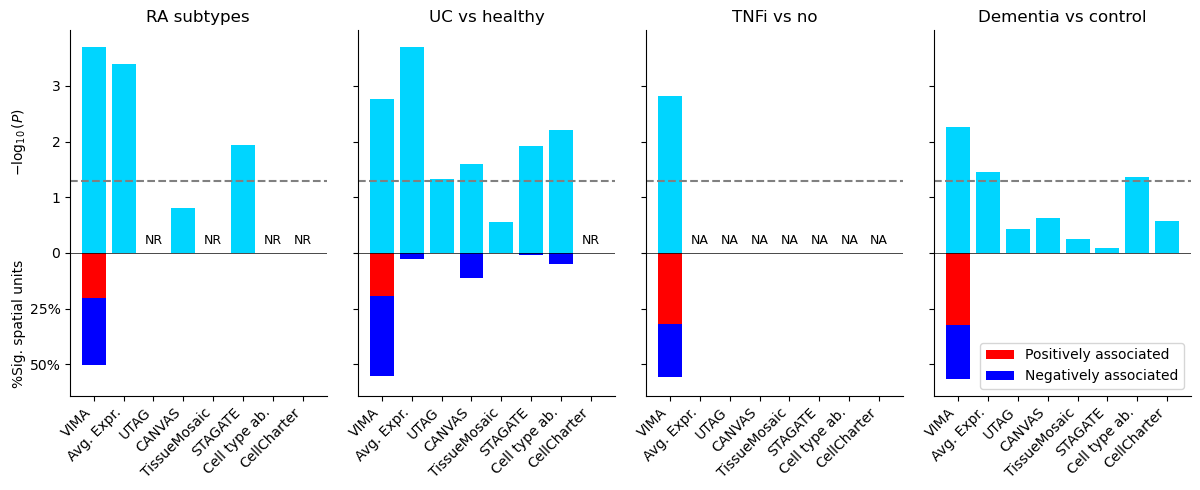

In [74]:
print('clusters, bonferroni')
make_plot(bonferroni, methodorder)
plt.savefig('../_supp/fig.benchmark.bonferroni.png', dpi=800)
plt.show()

print('clusters, omnibus')
make_plot(omnibus, methodorder)
plt.savefig('../_supp/fig.benchmark.omnibus.png', dpi=800)
plt.show()

print('microniches')
make_plot(microniche, methodorder)
plt.savefig('../_supp/fig.benchmark.microniche.png', dpi=800)
plt.show()

print('harmonized -> clusters, bonferroni')
make_plot(harmonized, methodorder)
plt.savefig('../_supp/fig.benchmark.harmonized.png', dpi=800)
plt.show()

print('harmonized -> microniches')
make_plot(harmonized_microniche, methodorder)
plt.savefig('../_supp/fig.benchmark.harmonized_microniche.png', dpi=800)
plt.show()

